# Wine Quality Dataset - Comprehensive Exploratory Data Analysis (EDA)

## Student Name:  Mehr Ali
## Course: AI/ML Internship
## Submission Date: 6/16/2026

This notebook performs a complete exploratory data analysis of the Wine Quality dataset. The dataset contains physicochemical measurements of wine samples along with a quality rating. EDA is important because it helps reveal data structure, detect quality issues, identify relationships between variables, and generate evidence-based insights before modeling. The main objectives here are to inspect the dataset, clean it if needed, study distributions, analyze relationships, and summarize the strongest patterns connected to wine quality.

# 2. Setup & Library Imports

This section imports the core libraries used throughout the analysis. `pandas` is used for data loading and manipulation, `numpy` supports numerical operations, `matplotlib` is used for plotting, and `seaborn` provides statistical visualizations with cleaner aesthetics. A consistent plotting style is also set so the notebook looks polished and readable.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['figure.dpi'] = 120

print('Libraries imported successfully.')

Libraries imported successfully.


# 3. Data Loading

This section loads the uploaded CSV file into a pandas DataFrame and performs the first direct look at the data. Showing the first rows, last rows, shape, and column names helps confirm that the file was read correctly and gives an immediate sense of the variables available for analysis.

In [18]:
df = pd.read_csv('WineQT.csv')

print('First 5 rows:')
display(df.head())

print('Last 5 rows:')
display(df.tail())

print('Dataset shape:', df.shape)
print('Column names:')
print(df.columns.tolist())

First 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Last 5 rows:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1597


Dataset shape: (1143, 13)
Column names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'Id']


# 4. Dataset Inspection

The next step is to inspect the structure of the dataset in more detail. `info()` reveals the data types and non-null counts, while `describe()` summarizes the central tendency and spread of the numeric columns. Together, these checks help identify the number of observations, the number of features, and whether the variables are in a usable format for analysis.

In [19]:
print('Dataset info:')
df.info()

print('\nDescriptive statistics:')
display(df.describe())

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB

Descriptive statistics:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


# 5. Data Cleaning

This section checks the dataset for missing values, duplicate records, and data-type issues. The column names are also standardized to snake_case for cleaner code and easier reference in later analysis. Even when the dataset is already clean, documenting these checks is an important part of a complete EDA workflow.

In [20]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

missing_values = df.isnull().sum()
duplicate_rows = df.duplicated().sum()

print('Missing values by column:')
print(missing_values.to_string())

print('\nNumber of duplicate rows:', duplicate_rows)

print('\nData types:')
print(df.dtypes.to_string())

print('\nPreview of cleaned column names:')
print(df.columns.tolist())

Missing values by column:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
id                      0

Number of duplicate rows: 0

Data types:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
ph                      float64
sulphates               float64
alcohol                 float64
quality                   int64
id                        int64

Preview of cleaned column names:
['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'p

# 6. Univariate Analysis

Univariate analysis studies one variable at a time. Here, the goal is to understand the distribution of the most important features in the dataset, especially the quality rating and several chemical properties. This helps reveal skewness, outliers, and the overall spread of the data before comparing variables against each other.

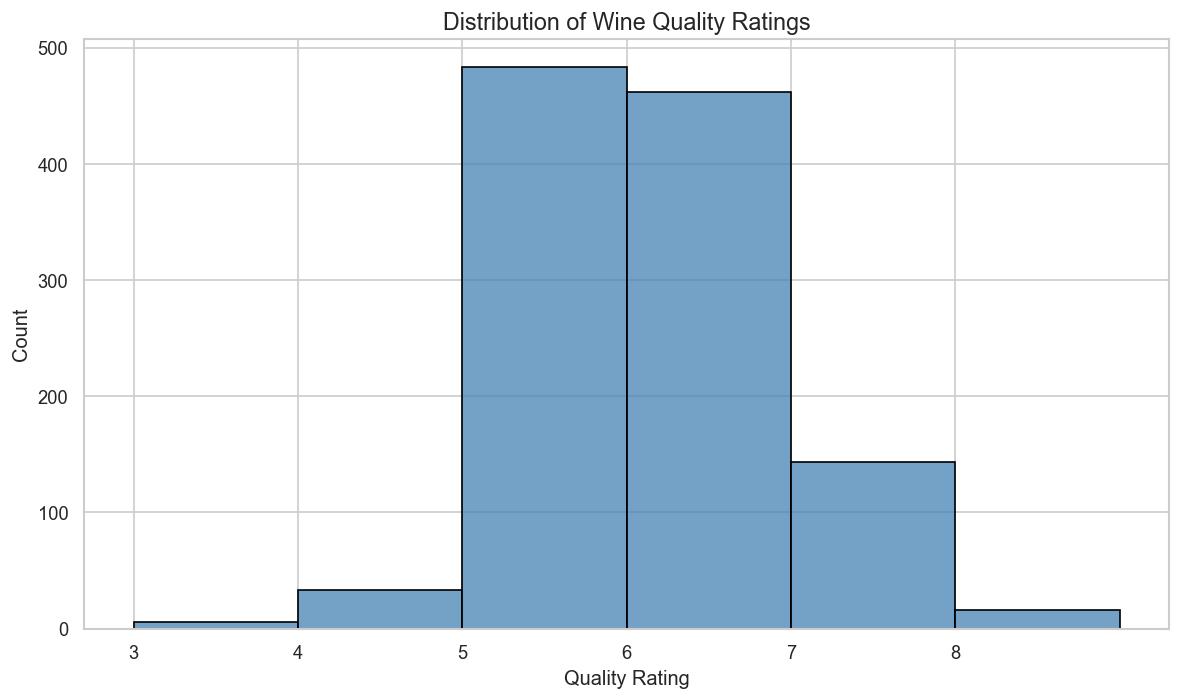

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['quality'], bins=range(df['quality'].min(), df['quality'].max() + 2), kde=False, color='steelblue', edgecolor='black')
plt.title('Distribution of Wine Quality Ratings')
plt.xlabel('Quality Rating')
plt.ylabel('Count')
plt.xticks(sorted(df['quality'].unique()))
plt.tight_layout()
plt.show()

The quality histogram shows how wine ratings are distributed across the sample. This plot helps reveal whether the dataset is balanced or concentrated around certain scores. A clustering of observations around the middle quality values would suggest that most wines are rated as average rather than extremely poor or excellent.

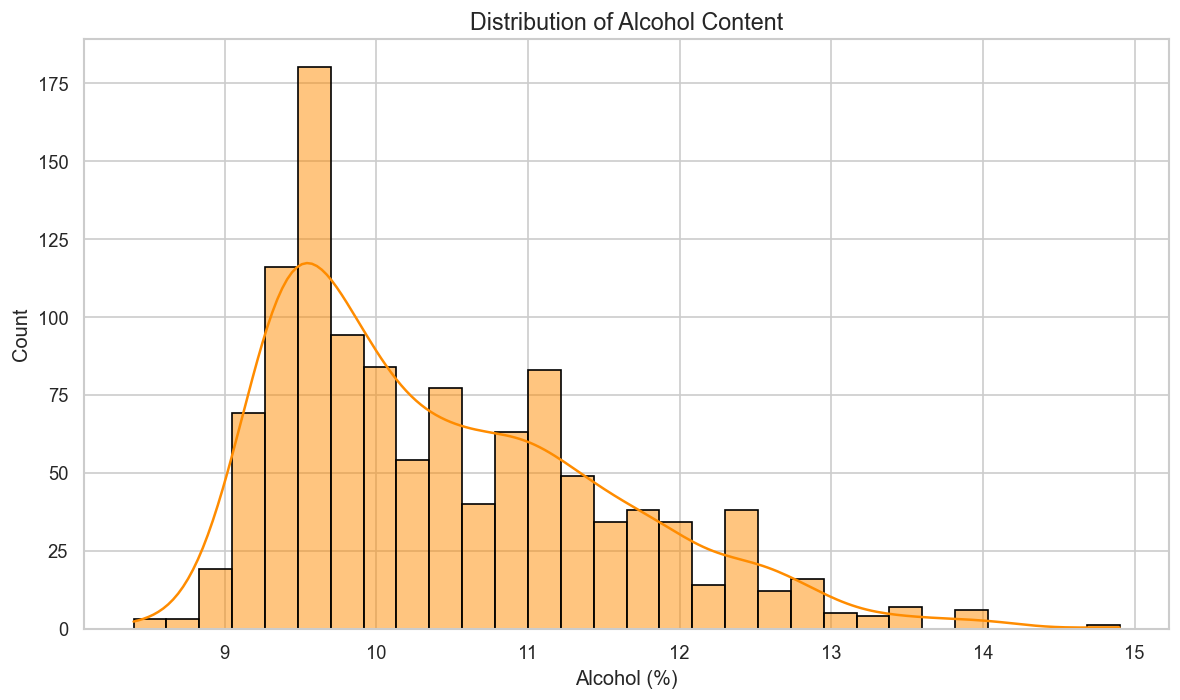

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(df['alcohol'], bins=30, kde=True, color='darkorange', edgecolor='black')
plt.title('Distribution of Alcohol Content')
plt.xlabel('Alcohol (%)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The alcohol distribution is important because alcohol is often one of the strongest drivers of wine perception and quality. A right-skewed distribution would mean most wines have moderate alcohol levels, while a long upper tail would indicate a smaller set of stronger wines.

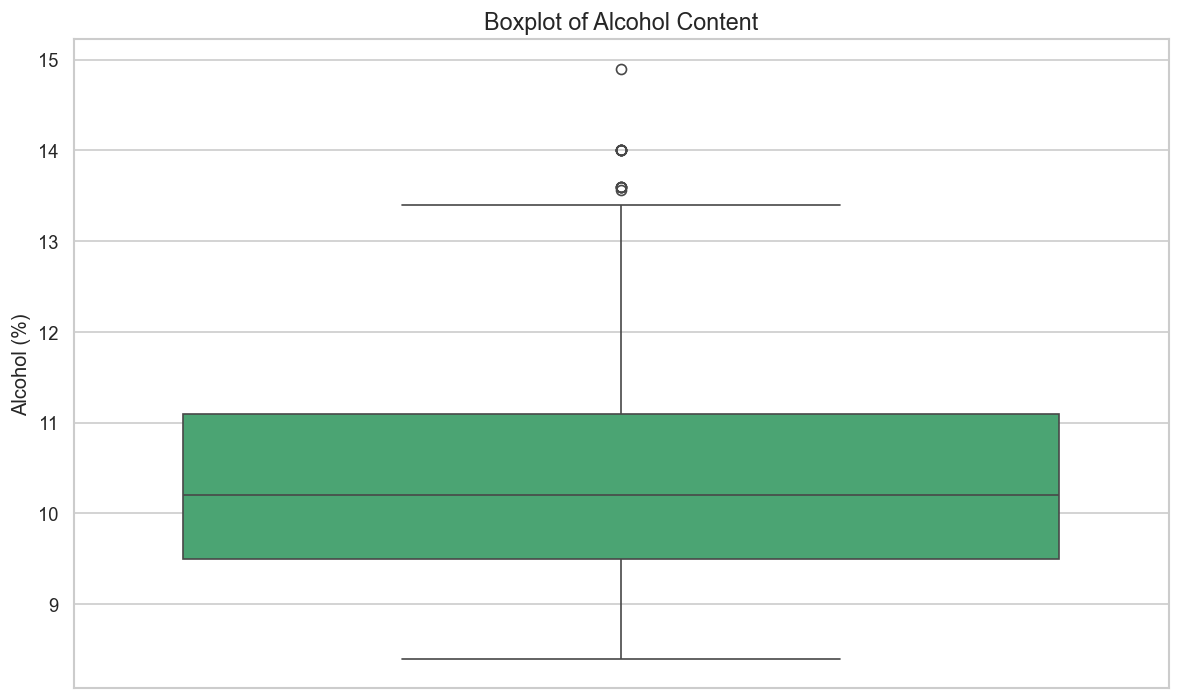

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['alcohol'], color='mediumseagreen')
plt.title('Boxplot of Alcohol Content')
plt.ylabel('Alcohol (%)')
plt.tight_layout()
plt.show()

The alcohol boxplot highlights the center of the distribution, the spread of the middle 50% of values, and any outliers. A few extreme points would suggest that the dataset includes some unusually strong wines, which is common in real-world food and beverage data.

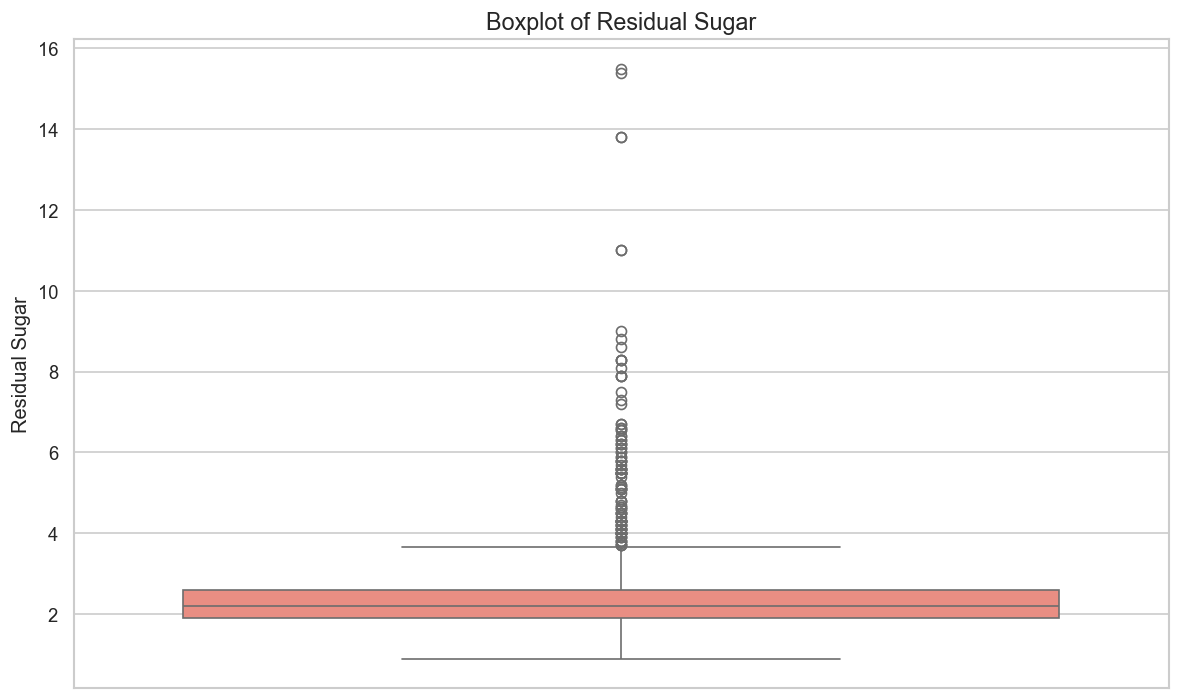

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['residual_sugar'], color='salmon')
plt.title('Boxplot of Residual Sugar')
plt.ylabel('Residual Sugar')
plt.tight_layout()
plt.show()

Residual sugar often shows strong skewness in wine datasets because many wines are dry, while fewer samples contain very high sugar levels. This boxplot helps identify whether the distribution contains extreme outliers or a compressed middle range.

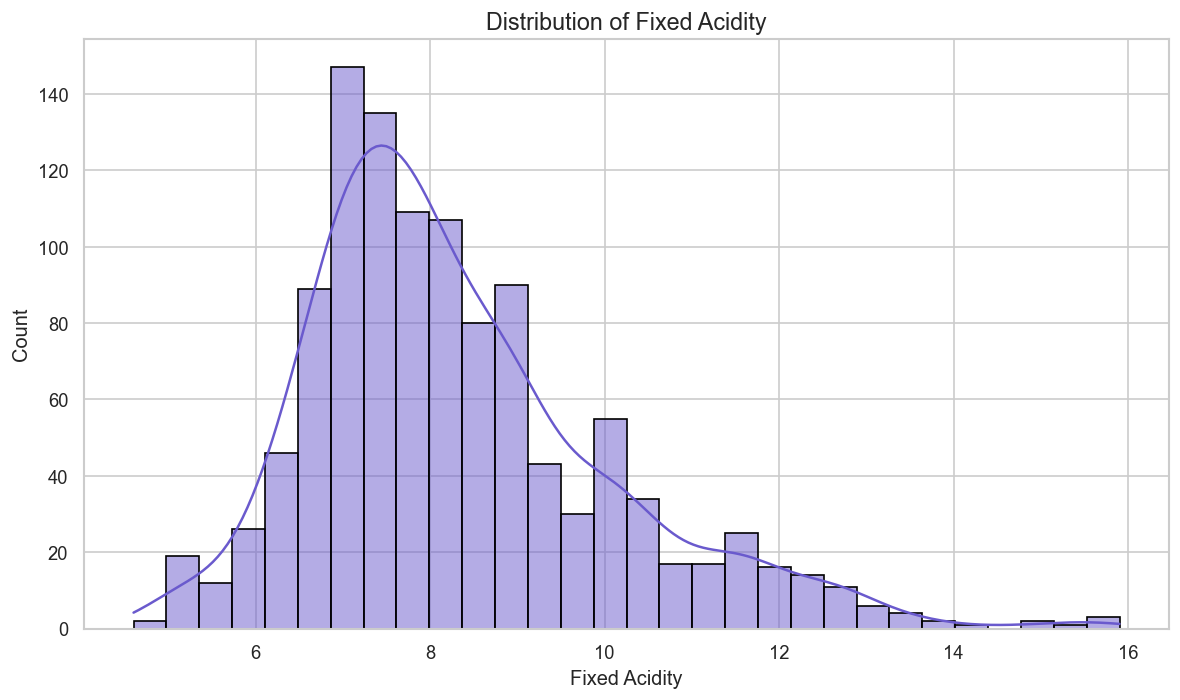

In [9]:
plt.figure(figsize=(10, 6))
sns.histplot(df['fixed_acidity'], bins=30, kde=True, color='slateblue', edgecolor='black')
plt.title('Distribution of Fixed Acidity')
plt.xlabel('Fixed Acidity')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

The fixed acidity distribution gives a sense of how concentrated the wine samples are around typical acid levels. The KDE curve helps reveal whether the feature is approximately symmetric or whether it leans toward a skewed shape.

# 7. Bivariate Analysis

Bivariate analysis examines how two variables move together. In this section, the focus is on whether chemical properties such as alcohol and acidity help explain the wine quality score. These plots are especially useful for spotting trends, group differences, and possible linear relationships.

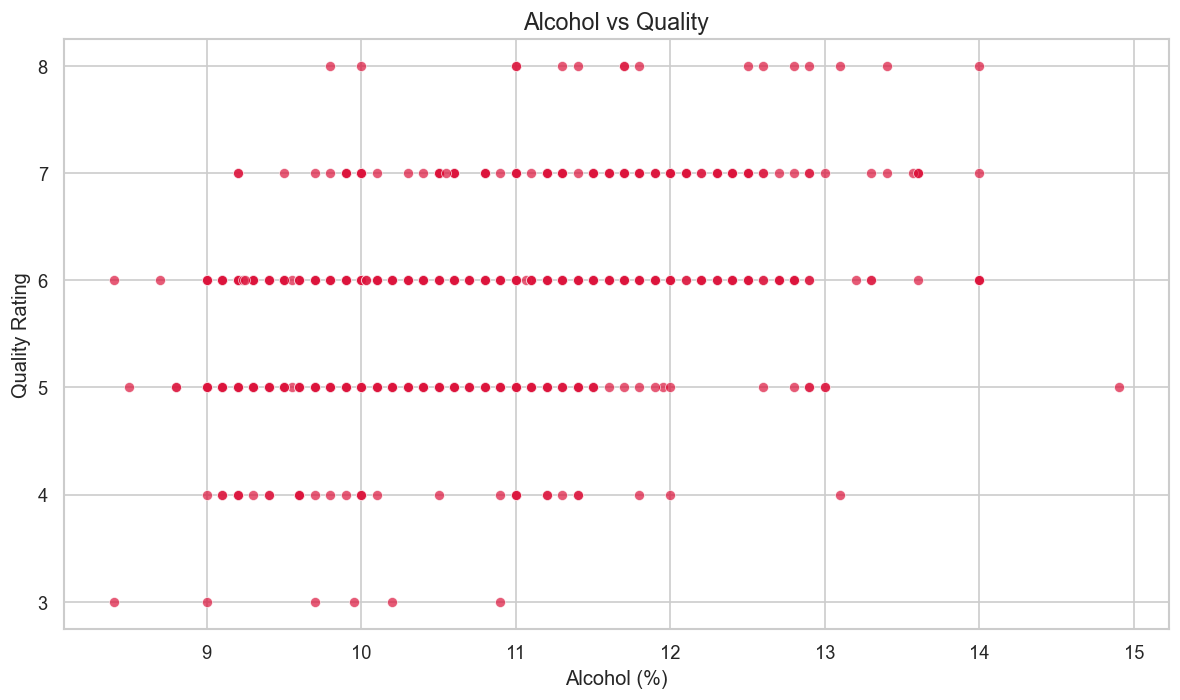

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='alcohol', y='quality', alpha=0.7, color='crimson')
plt.title('Alcohol vs Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality Rating')
plt.tight_layout()
plt.show()

The scatter plot compares alcohol content with quality ratings. If the points tend to rise as alcohol increases, that suggests a positive association and indicates that stronger wines may receive better scores.

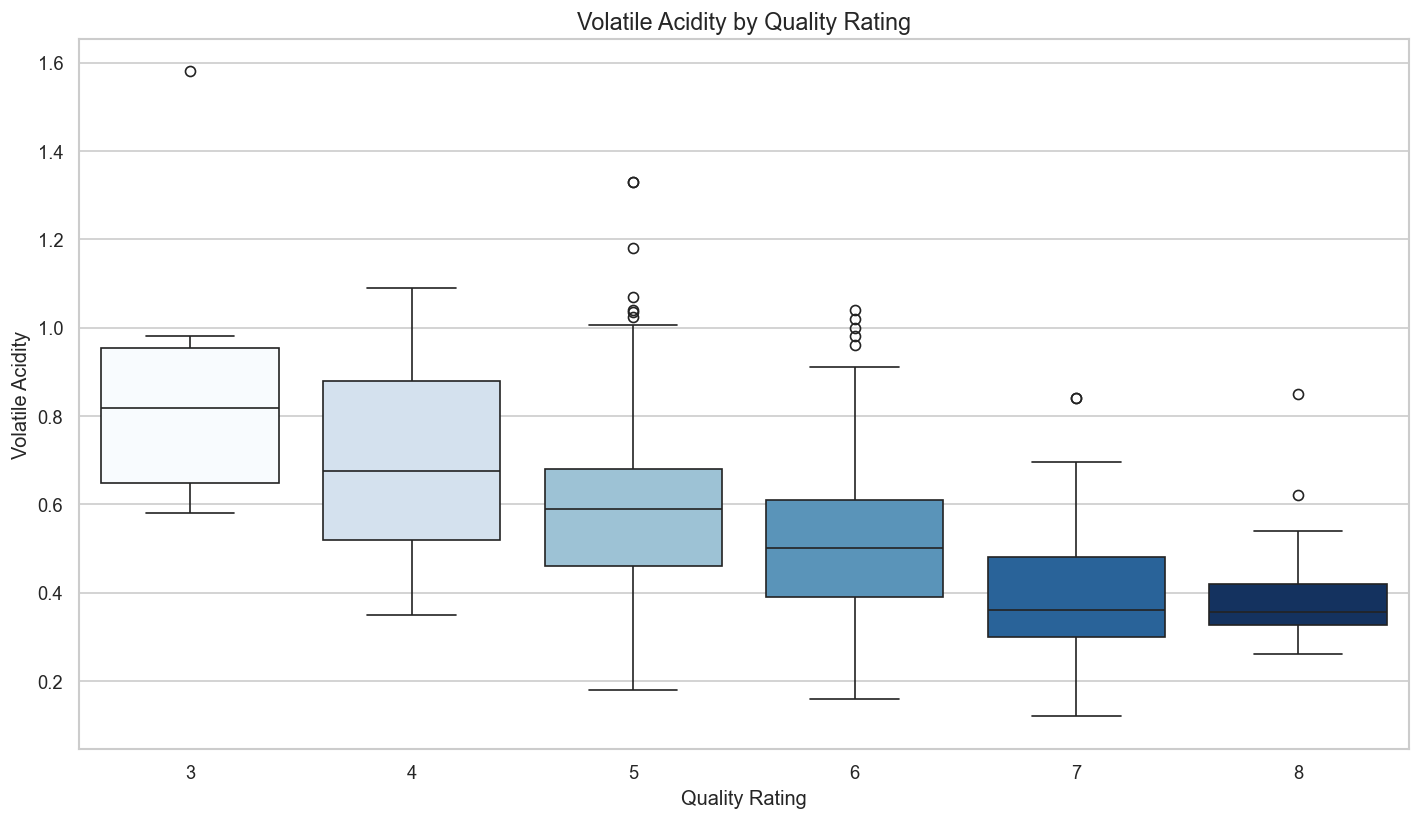

In [15]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='quality', y='volatile_acidity', hue='quality', palette='Blues', legend=False)
plt.title('Volatile Acidity by Quality Rating')
plt.xlabel('Quality Rating')
plt.ylabel('Volatile Acidity')
plt.tight_layout()
plt.show()

The grouped box plot shows how volatile acidity changes across quality categories. A downward shift in the boxes for higher quality levels would indicate that low volatile acidity is associated with better wine ratings.

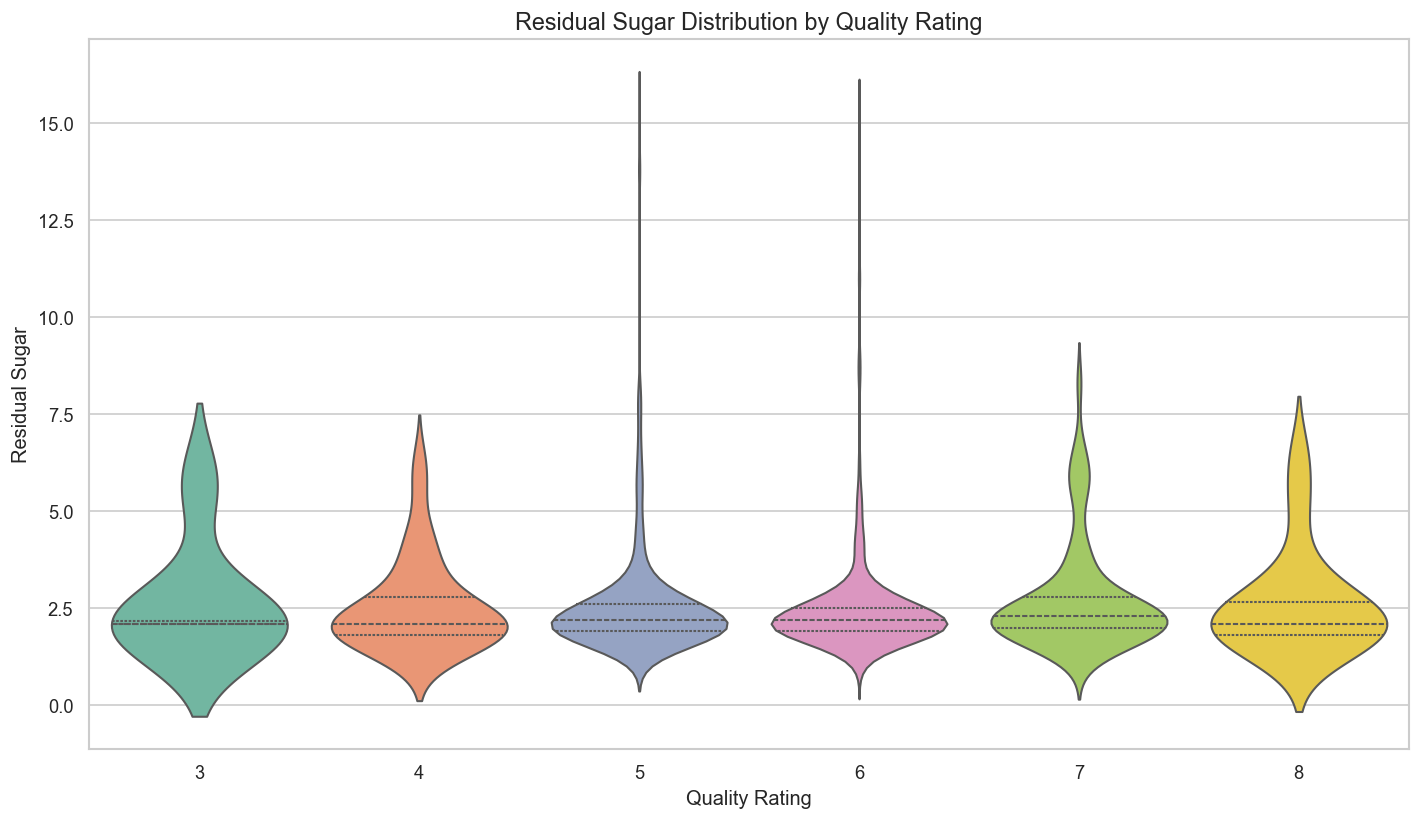

In [16]:
plt.figure(figsize=(12, 7))
sns.violinplot(data=df, x='quality', y='residual_sugar', inner='quartile', hue='quality', palette='Set2', legend=False)
plt.title('Residual Sugar Distribution by Quality Rating')
plt.xlabel('Quality Rating')
plt.ylabel('Residual Sugar')
plt.tight_layout()
plt.show()

The violin plot combines distribution shape with summary statistics. It is useful here because it shows whether residual sugar differs much across quality ratings and whether a few unusual wines are driving the pattern.

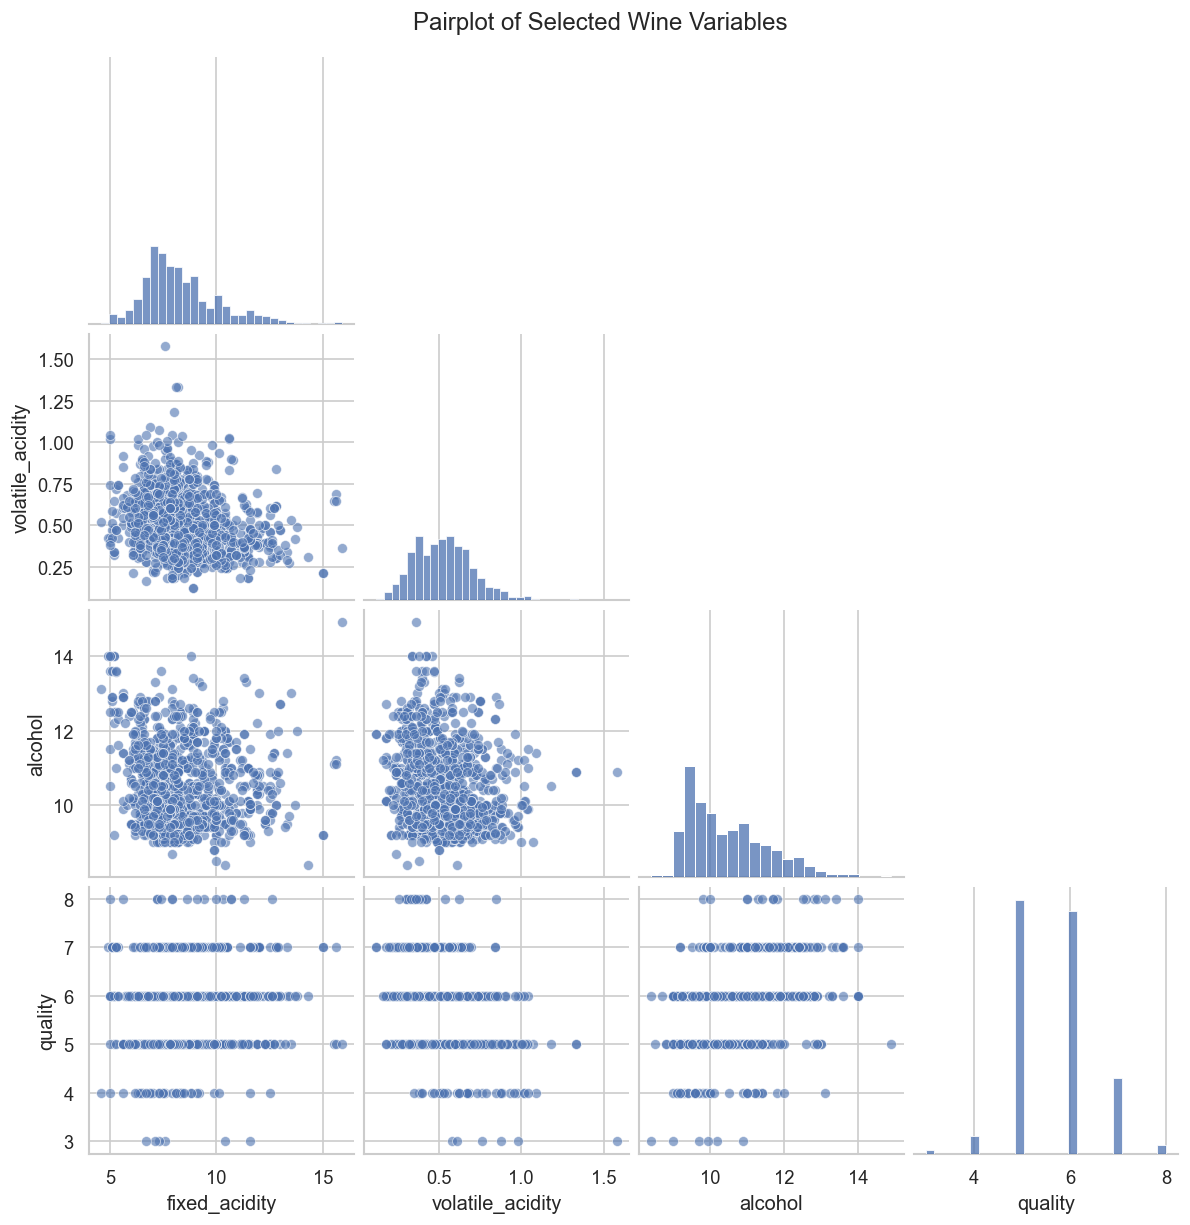

In [13]:
sns.pairplot(df[['fixed_acidity', 'volatile_acidity', 'alcohol', 'quality']], corner=True, plot_kws={'alpha': 0.6, 's': 35})
plt.suptitle('Pairplot of Selected Wine Variables', y=1.02)
plt.show()

The pairplot gives a compact view of several relationships at once. It helps confirm whether alcohol moves with quality and whether acidity variables tend to cluster differently for lower and higher quality wines.

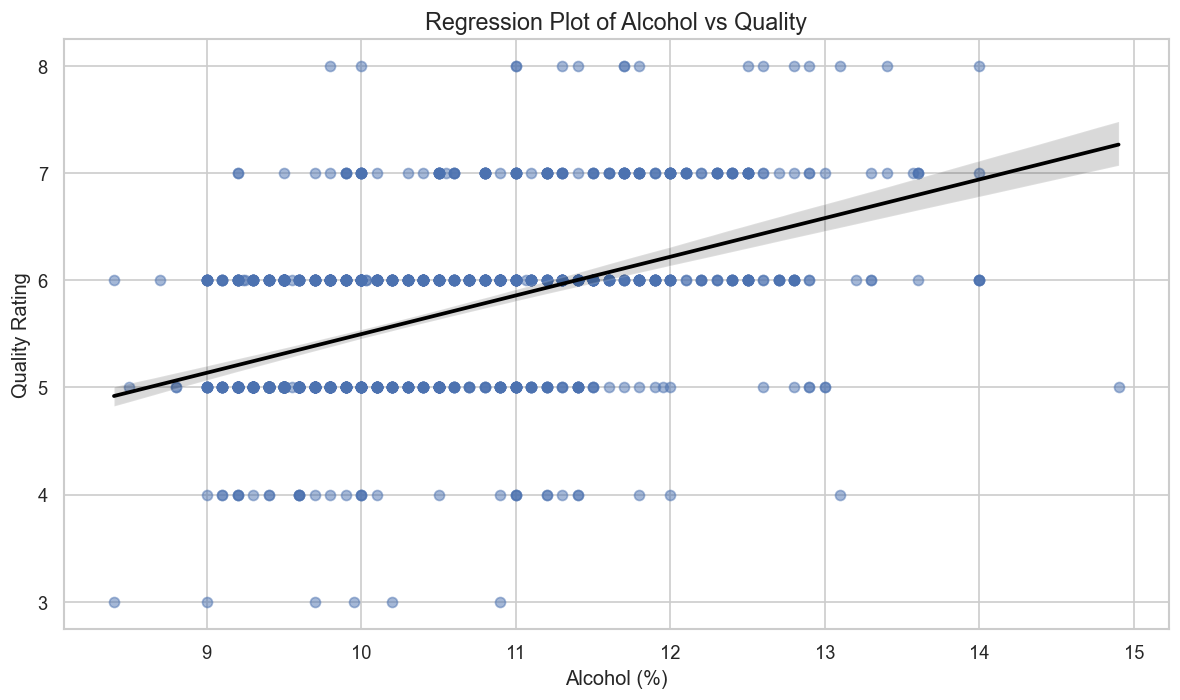

In [14]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='alcohol', y='quality', scatter_kws={'alpha': 0.5}, line_kws={'color': 'black'})
plt.title('Regression Plot of Alcohol vs Quality')
plt.xlabel('Alcohol (%)')
plt.ylabel('Quality Rating')
plt.tight_layout()
plt.show()

The regression plot adds a fitted trend line to the scatter plot, making the direction of the relationship easier to evaluate. A positive slope would strengthen the idea that higher alcohol content is linked with better quality scores.